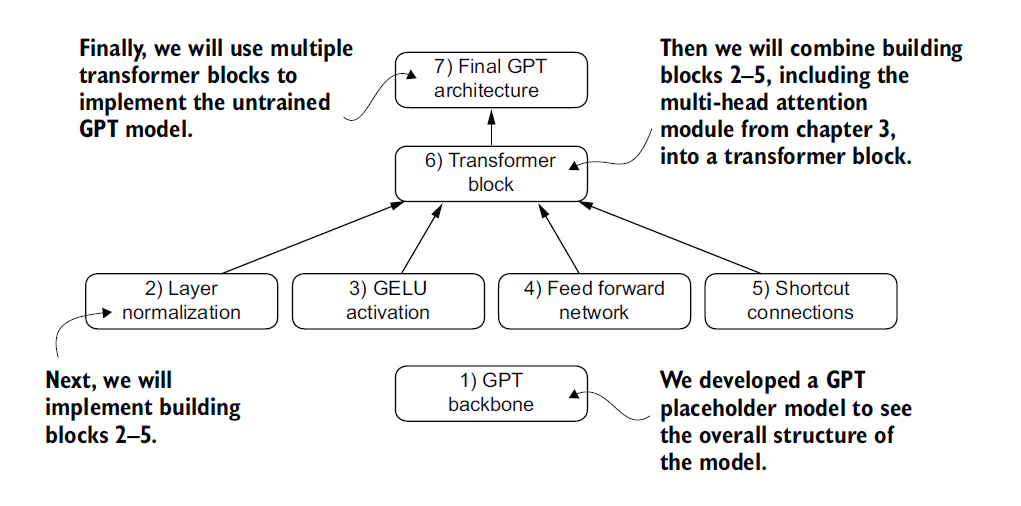

In [1]:
import torch
import torch.nn as nn

In [2]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,        # Vocabulary Size
    "context_length": 1024,     # Context Length
    "emb_dim": 768,             # Embedding Dimension
    "n_heads": 12,              # Number of attention heads
    "n_layers": 12,             # Number of layers
    "drop_rate": 0.1,           # Dropout rate
    "qkv_bias": False           # Query-Key-Value bias
}

# Placeholder for GPT Model Class (GPT backbone)


In [ ]:
class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg['vocab_size'], cfg['emb_dim'])
        self.pos_emb = nn.Embedding(cfg['context_length'], cfg['emb_dim'])
        self.drop_emb = nn.Dropout(cfg['drop_rate'])

        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg)
            for _ in range(cfg['n_layers'])]
        )

        self.final_norm = DummyLayerNorm(cfg['emb_dim'])

        self.out_head = nn.Linear(
            cfg['emb_dim'], cfg['vocab_size'], bias=False
        )
    
    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(
            torch.arange(seq_len, device=in_idx.device)
        )

        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
    
    def forward(self, x):
        return x

class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()
    
    def forward(self, x):
        return x


In [38]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
batch = []
txt1 = "Every effort moves you"
txt2 = "Every day holds a"
batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)
print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


In [ ]:
torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)
logits = model(batch)
print("Output shape:", logits.shape)
print(logits)

# Normalizing activations with layer normalization

## Intuition

In [3]:
torch.manual_seed(123)
batch_example = torch.randn(2, 5)
print(batch_example)
layer = nn.Sequential(nn.Linear(5, 6), nn.ReLU())
out = layer(batch_example)
print(out)

tensor([[-0.1115,  0.1204, -0.3696, -0.2404, -1.1969],
        [ 0.2093, -0.9724, -0.7550,  0.3239, -0.1085]])
tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


In [4]:
mean = out.mean(dim=-1, keepdim=True)
var = out.var(dim=-1, keepdim=True)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


Our goal while normalizing is to keep the mean 0 and variance 1. It is also called unit variance

In [5]:
out_norm = (out - mean) / torch.sqrt(var)
mean = out_norm.mean(dim=-1, keepdim=True)
var = out_norm.var(dim=-1, keepdim=True)
print("Normalized layer outputs:\n", out_norm)
print("Mean:\n", mean)
print("Variance:\n", var)

Normalized layer outputs:
 tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)
Mean:
 tensor([[9.9341e-09],
        [0.0000e+00]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


We can see that the mean is very close to 0 and variance 0

In [6]:
torch.set_printoptions(sci_mode=False)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[    0.0000],
        [    0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


## Layer Normalization Class

In [7]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5         # We take this as a constant value to avoid denominator being zero while normalizing
        self.scale = nn.Parameter(torch.ones(emb_dim))      # Trainable parameters so that LLMs can adjust them accordingly during training
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        variance = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(variance + self.eps)
        return self.scale * norm_x + self.shift

In [8]:
torch.manual_seed(123)
batch_example = torch.randn(2, 5)
print(batch_example)
ln = LayerNorm(emb_dim=5)
out_ln = ln(batch_example)
mean = out_ln.mean(dim=-1, keepdim=True)
var = out_ln.var(dim=-1, unbiased=False, keepdim=True)
print("Mean:\n", mean)
print("Variance:\n", var)

tensor([[-0.1115,  0.1204, -0.3696, -0.2404, -1.1969],
        [ 0.2093, -0.9724, -0.7550,  0.3239, -0.1085]])
Mean:
 tensor([[    -0.0000],
        [     0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


# FFN with GELU

## GELU

In [9]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()
    
    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi))*
            (x + 0.44715 * torch.pow(x, 3))
        ))

In [ ]:
# import matplotlib.pyplot as plt
# gelu, relu = GELU(), nn.ReLU()
# x = torch.linspace(-3, 3, 100)
# y_gelu, y_relu = gelu(x), relu(x)
# plt.figure(figsize=(8, 3))
# for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
#     plt.subplot(1, 2, i)
#     plt.plot(x, y)
#     plt.title(f"{label} activation function")
#     plt.xlabel("x")
#     plt.ylabel(f"{label}(x)")
#     plt.grid(True)
#     plt.tight_layout()
#     plt.show()

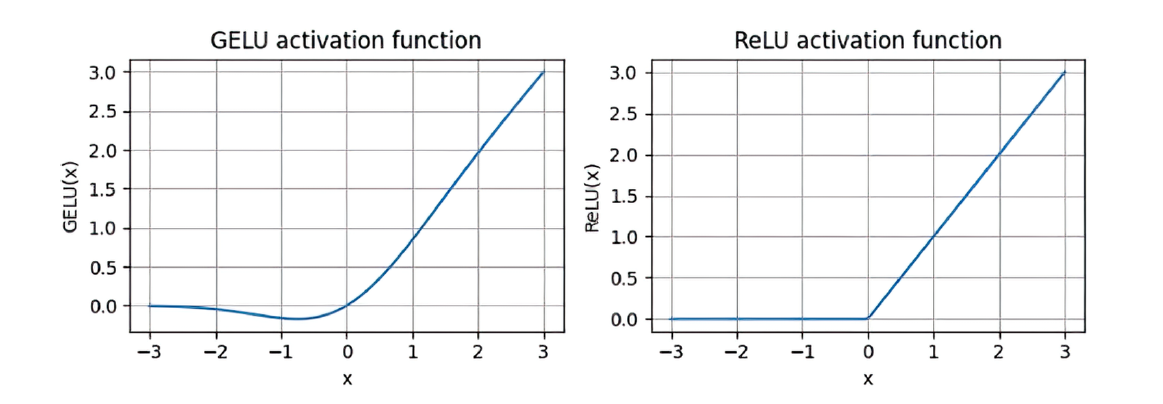

## FFN

In [10]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg['emb_dim'], 4 * cfg['emb_dim']),
            GELU(),
            nn.Linear(4 * cfg['emb_dim'], cfg['emb_dim']),
        )
    
    def forward(self, x):
        return self.layers(x)

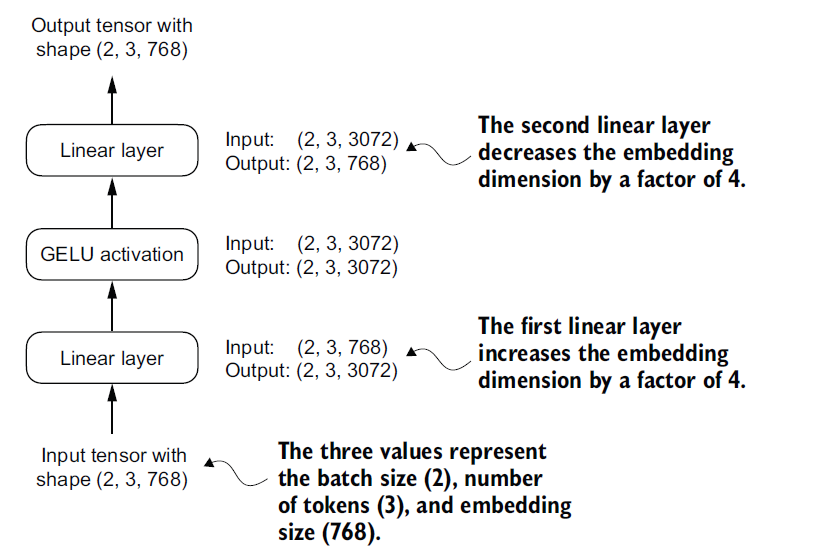

In [11]:
ffn = FeedForward(GPT_CONFIG_124M)
x = torch.rand(2, 3, 768)
out = ffn(x)
print(out.shape)

torch.Size([2, 3, 768])


# Shortcut Connections

In [ ]:
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()

        self.use_shorcut = use_shortcut
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]), GELU())
        ])
    
    def forward(self, x):
        for layer in self.layers:
            layer_output = layer(x)
            if self.use_shorcut and x.shape == layer_output.shape:
                x = x + layer_output
            else:
                x = layer_output
        return x

# class ExampleDeepNeuralNetworkDiff(nn.Module):
#     def __init__(self, layer_sizes, use_shortcut):
#         super().__init__()

#         self.use_shorcut = use_shortcut
#         self.layers = nn.Sequential(
#             nn.Linear(layer_sizes[0], layer_sizes[1]),
#             GELU(),
#             nn.Linear(layer_sizes[1], layer_sizes[2]),
#             GELU(),
#             nn.Linear(layer_sizes[2], layer_sizes[3]),
#             GELU(),
#             nn.Linear(layer_sizes[3], layer_sizes[4]),
#             GELU(),
#             nn.Linear(layer_sizes[4], layer_sizes[5])
#         )    
#     def forward(self, x):
#         for layer in self.layers:
#             layer_output = layer(x)
#             if self.use_shorcut and x.shape == layer_output.shape:
#                 x = x + layer_output
#             else:
#                 x = layer_output
#         return x
    
# The above version of only 1 sequential block won't work as Linear Layer and GELU will be counted as individual iterations or layers. While in case of the original solution each iteration
# -is a combination of both linear layer followed by a GELU

In [28]:
layer_sizes = [3, 3, 3, 3, 3, 1]
sample_input = torch.tensor([[1., 0., -1.]])
torch.manual_seed(123)
model_without_shortcut = ExampleDeepNeuralNetwork(
layer_sizes, use_shortcut=False
)

In [29]:
def print_gradients(model, x):
    output = model(x)
    target = torch.tensor([[0.]])
    loss = nn.MSELoss()
    loss = loss(output, target)
    loss.backward()

    for name, param in model.named_parameters():
        if 'weight' in name:
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")

print_gradients(model_without_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.000204713229322806
layers.1.0.weight has gradient mean of 0.00012317951768636703
layers.2.0.weight has gradient mean of 0.0007344746845774353
layers.3.0.weight has gradient mean of 0.0013871215051040053
layers.4.0.weight has gradient mean of 0.005026496481150389


In [30]:
torch.manual_seed(123)
model_with_shortcut = ExampleDeepNeuralNetwork(
layer_sizes, use_shortcut=True
)
print_gradients(model_with_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.29920274019241333
layers.1.0.weight has gradient mean of 0.2749510407447815
layers.2.0.weight has gradient mean of 0.454661101102829
layers.3.0.weight has gradient mean of 0.3629586398601532
layers.4.0.weight has gradient mean of 1.763088583946228


In [31]:
sample_input.shape

torch.Size([1, 3])

# Coding Attention and Linear Layers in a Transformer blocks

In [32]:
# Importing Attention module from the chapter 3 
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out,context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert (d_out % num_heads == 0), \
        "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )
    
    def forward(self, x):
        b, num_tokens, d_in = x.shape
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        keys = keys.transpose(1, 2)         # Shape is changed from (batch, # tokens, # heads, head_dim) -> (batch, # heads, # tokens, head_dim)
        queries = queries.transpose(1, 2)   # Shape is changed from (batch, # tokens, # heads, head_dim) -> (batch, # heads, # tokens, head_dim)
        values = values.transpose(1, 2)     # Shape is changed from (batch, # tokens, # heads, head_dim) -> (batch, # heads, # tokens, head_dim)

        attn_scores = queries @ keys.transpose(2, 3) # Compute dot product for each head
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        context_vec = (attn_weights @ values).transpose(1, 2)   # shape = (batch, # tokens, # heads, head_dim)

        context_vec = context_vec.contiguous().view(
                        b, num_tokens, self.d_out
                        )
        
        context_vec = self.out_proj(context_vec)
        return context_vec


In [43]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg['emb_dim'],
            d_out=cfg['emb_dim'],
            context_length=cfg['context_length'],
            num_heads=cfg['n_heads'],
            dropout=cfg['drop_rate'],
            qkv_bias=cfg['qkv_bias']
        )
        self.ff=FeedForward(cfg)
        self.norm1 = LayerNorm(cfg['emb_dim'])
        self.norm2 = LayerNorm(cfg['emb_dim'])
        self.drop_shortcut = nn.Dropout(cfg['drop_rate'])

    
    def forward(self, x):
        print("Shape of input in transformer block is:", x.shape)
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut
        return x


In [44]:
torch.manual_seed(123)
x = torch.rand(2, 4, 768)
block = TransformerBlock(GPT_CONFIG_124M)
output = block(x)
print("Input shape:", x.shape)
print("Output shape:", output.shape)

Shape of input in transformer block is: torch.Size([2, 4, 768])
Input shape: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])


# Coding the GPT Model

In [ ]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg['vocab_size'], cfg['emb_dim'])
        self.pos_emb = nn.Embedding(cfg['context_length'], cfg['emb_dim'])
        self.drop_emb = nn.Dropout(cfg['drop_rate'])

        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg['n_layers'])]
        )

        self.final_norm = LayerNorm(cfg['emb_dim'])
        self.out_head = nn.Linear(
            cfg['emb_dim'], cfg['vocab_size']
        )
    
    def forward(self, in_idx):
        print("Shape of in_idx", in_idx.shape)
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        print("Shape of tok_embeds", tok_embeds.shape)
        pos_embeds = self.pos_emb(
            torch.arange(seq_len, device=in_idx.device))
        
        x = tok_embeds + pos_embeds
        print("Shape after applying position embeddings:", x.shape)
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

In [51]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
out = model(batch)
print("Input batch:\n", batch)
print(f"Shape of batch: {batch.shape}")
print("\nOutput shape:", out.shape)
print(out)

Shape of in_idx torch.Size([2, 4])
Shape of tok_embeds torch.Size([2, 4, 768])
Shape after applying position embeddings: torch.Size([2, 4, 768])
Shape of input in transformer block is: torch.Size([2, 4, 768])
Shape of input in transformer block is: torch.Size([2, 4, 768])
Shape of input in transformer block is: torch.Size([2, 4, 768])
Shape of input in transformer block is: torch.Size([2, 4, 768])
Shape of input in transformer block is: torch.Size([2, 4, 768])
Shape of input in transformer block is: torch.Size([2, 4, 768])
Shape of input in transformer block is: torch.Size([2, 4, 768])
Shape of input in transformer block is: torch.Size([2, 4, 768])
Shape of input in transformer block is: torch.Size([2, 4, 768])
Shape of input in transformer block is: torch.Size([2, 4, 768])
Shape of input in transformer block is: torch.Size([2, 4, 768])
Shape of input in transformer block is: torch.Size([2, 4, 768])
Input batch:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])
Shap

In [ ]:
class ff_rev(nn.Module):
    def __init__(self, emb_dim):
        self.layers = nn.Sequential(
            nn.Linear(emb_dim, emb_dim * 4)
            GELU()
            nn.Linear(emb_dim * 4, emb_dim)
        )

    
    def forward(self, x):
        return self.layers(x)

class TrBlock(nn.Module):
    def __init__(self, cfg):


# Generating Text